
# 02 — เรขาคณิตลำบีมเรดาร์สำหรับการวิเคราะห์ภูมิประเทศ
## Radar Beam Geometry for Terrain Analysis

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก

- **00 — Setup and Download SRTM DEM**
- **01 — SRTM DEM Preprocessing for Radar–Terrain Analysis**

โดย Notebook 01 ได้สร้าง DEM สำหรับการวิเคราะห์ที่มี

- CRS: **WGS 84 / UTM Zone 47N (EPSG:32647)**
- spatial resolution: **1,000 m**
- terrain representation: **maximum-elevation resampling**
- valid DEM coverage ครบภายในรัศมี 240 km ของทั้ง 4 sites

Notebook นี้จะยัง **ไม่คำนวณ PBB หรือ CBB**

เป้าหมายคือทำความเข้าใจฟิสิกส์และเรขาคณิตของลำบีมก่อน เพื่อไม่ให้การใช้ `wradlib` ในบทต่อไปกลายเป็นการใช้ library แบบ black box

$$
\boxed{
\text{Radar position}
+
\text{Range}
+
\text{Elevation angle}
+
\text{Earth curvature}
+
\text{Atmospheric refraction}
\rightarrow
\text{Beam height}
}
$$


### รูปแบบสมการสำหรับ Google Colab

Notebook ชุดนี้ใช้รูปแบบ MathJax/LaTeX ที่ Google Colab แสดงผลได้เสถียร

- สมการในบรรทัดใช้เครื่องหมาย dollar หนึ่งคู่
- สมการแยกบรรทัดใช้เครื่องหมาย dollar สองคู่

สมการทั้งหมดใน Notebook นี้และบทถัดไปจะใช้มาตรฐานเดียวกัน เพื่อให้แสดงผลได้ถูกต้องใน Google Colab


## 1. คำถามนำของบทเรียน

ก่อนรันโค้ด ลองพิจารณาคำถามต่อไปนี้

1. ลำบีมที่ elevation angle $0.5^\circ$ สูงจาก radar เท่าใดที่ระยะ 50, 100, 150, 200 และ 240 km?
2. เหตุใดลำบีมจึงไม่ได้เดินทางเป็นเส้นตรงที่ระดับคงที่เหนือพื้นโลก?
3. ค่า $k=4/3$ ใน standard refraction model มีความหมายอย่างไร?
4. เหตุใด beamwidth จึงสำคัญต่อการวิเคราะห์ภูเขาบดบังลำบีม?
5. ถ้า beamwidth เท่ากับ $1^\circ$ ลำบีมที่ nominal elevation $0.5^\circ$ มีขอบล่างอยู่ที่มุมประมาณเท่าใด?
6. Radar site ที่อยู่สูงกว่า จะทำให้ **beam geometry relative to the antenna** เปลี่ยนหรือไม่?
7. Radar site ที่อยู่สูงกว่า จะทำให้ **beam altitude MSL** เปลี่ยนหรือไม่?

คำถามเหล่านี้ต้องตอบได้ก่อนเข้าสู่ PBB/CBB



## 2. Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ

- แยกความหมายของ **slant range, ground distance, azimuth และ elevation angle**
- อธิบายผลของ Earth curvature ต่อระดับลำบีม
- อธิบายแนวคิด **effective Earth radius**
- คำนวณ beam-centre height ด้วย $k=4/3$
- อธิบายความหมายของ **beamwidth** และ **half-power / −3 dB beam edges**
- คำนวณ upper และ lower beam edges
- เปรียบเทียบ elevation angles $0.5^\circ$, $1.0^\circ$, $1.5^\circ$ และ $2.0^\circ$
- แยกความแตกต่างระหว่าง **beam height above antenna** กับ **beam altitude MSL**
- ใช้ native DEM elevation ของแต่ละ radar site อย่างถูกต้อง
- อธิบายว่าทำไมเรายังไม่สามารถสรุป “site ที่ดีที่สุด” จากระดับความสูงของ site เพียงอย่างเดียวได้



# Part A — หลักการของ Radar Beam Geometry

## 3. พิกัดของลำบีมเรดาร์

Weather radar วัดข้อมูลบนระบบพิกัดเชิงขั้ว

$$
(r,\alpha,\theta)
$$

โดย

- $r$ = slant range จาก radar ไปยัง sample volume
- $\alpha$ = azimuth angle
- $\theta$ = elevation angle

ตัวอย่างเช่น elevation angle $0.5^\circ$ หมายถึงแกนกลางของลำบีมถูกยกขึ้นจากแนวราบประมาณครึ่งองศา

### Slant range ไม่เท่ากับ horizontal distance

Radar range bin โดยทั่วไปอ้างอิงระยะตามแนวลำบีม หรือ **slant range**

ดังนั้นในบทนี้ เมื่อระบุ

$$
r=240\ \mathrm{km}
$$

จะหมายถึงระยะตามแนวลำบีม ไม่ใช่ระยะราบบนแผนที่แบบ exact



## 4. Earth Curvature

ถ้าใช้ flat-Earth approximation อย่างง่าย ลำบีมที่ elevation angle $\theta$ จะมีความสูงประมาณ

$$
h_{\mathrm{flat}}
=
r\sin\theta
$$

แต่โลกมีความโค้ง ดังนั้นเมื่อระยะเพิ่มขึ้น พื้นผิวโลกจะโค้งออกจากแนว tangent ที่ตำแหน่ง radar

แม้ลำบีมที่ elevation angle ใกล้ $0^\circ$ ก็ไม่ได้คงอยู่ที่ความสูงเดียวจากพื้นผิวโลกเมื่อมองในกรอบ Earth-relative geometry

นี่เป็นเหตุผลสำคัญที่งาน radar meteorology ต้องพิจารณา Earth curvature



## 5. Atmospheric Refraction และ Effective Earth Radius

ดัชนีหักเหของบรรยากาศเปลี่ยนตามระดับความสูง ทำให้เส้นทางคลื่นเรดาร์โค้งได้

วิธีประมาณที่ใช้แพร่หลายใน radar meteorology คือ **effective Earth radius model**

$$
R_e^{*}
=
kR_e
$$

โดย

- $R_e$ = รัศมีโลก
- $k$ = effective-Earth-radius factor

สำหรับ standard refraction มักใช้

$$
k=\frac{4}{3}
$$

แทนที่จะจำลอง ray bending โดยตรง เราจึงมองเสมือนว่าโลกมีรัศมีใหญ่ขึ้นเป็น $4/3$ ของรัศมีจริง

> **ข้อควรระวัง:** $k=4/3$ เป็น atmospheric assumption ไม่ใช่ค่าคงที่สากลของบรรยากาศจริง สภาวะ superrefraction หรือ subrefraction สามารถทำให้เส้นทางลำบีมต่างจาก standard model ได้



## 6. สมการระดับความสูงของ Beam Centre

ให้

- $r$ = slant range
- $\theta$ = elevation angle
- $R_e^{*}=kR_e$

ระดับของ beam centre เหนือระดับ antenna สามารถประมาณได้จาก

$$
h(r,\theta)
=
\sqrt{
r^2
+
(kR_e)^2
+
2rkR_e\sin\theta
}
-
kR_e
$$

หาก antenna feed มีระดับ

$$
H_{\mathrm{radar,MSL}}
$$

ระดับลำบีมเหนือ mean sea level คือ

$$
H_{\mathrm{beam,MSL}}
=
H_{\mathrm{radar,MSL}}
+
h(r,\theta)
$$

และถ้ารู้ ground elevation กับ antenna height above ground

$$
H_{\mathrm{radar,MSL}}
=
H_{\mathrm{ground,MSL}}
+
H_{\mathrm{antenna,AGL}}
$$



## 7. Beamwidth: ลำบีมไม่ใช่เส้น

Radar beam มีความกว้างเชิงมุม

ในชุดบทเรียนนี้กำหนด nominal **one-way half-power beamwidth**

$$
\beta = 1.0^\circ
$$

ดังนั้นสำหรับ nominal elevation angle $\theta$ เราสามารถประมาณขอบล่างและขอบบนที่ระดับ half-power หรือประมาณ −3 dB ได้จาก

$$
\theta_{\mathrm{lower}}
=
\theta-\frac{\beta}{2}
$$

$$
\theta_{\mathrm{upper}}
=
\theta+\frac{\beta}{2}
$$

เช่น nominal elevation

$$
\theta=0.5^\circ
$$

เมื่อ $\beta=1^\circ$ จะได้

$$
\theta_{\mathrm{lower}}=0^\circ
$$

และ

$$
\theta_{\mathrm{upper}}=1^\circ
$$

จุดนี้สำคัญมากต่อ terrain blockage เพราะภูเขาอาจไม่ชน **beam centre** แต่ยังบัง **ส่วนล่างของ beam** ได้



## 8. Beam Radius แบบ Approximation

หากต้องการประมาณ physical half-width ของ beam อย่างง่าย

$$
a(r)
\approx
r\tan\left(\frac{\beta}{2}\right)
$$

เมื่อ $a(r)$ คือ half-power beam radius

ดังนั้น approximate beam diameter คือ

$$
D_{\mathrm{beam}}
\approx
2a(r)
$$

ที่ระยะไกล ลำบีมจึงมีหน้าตัดใหญ่ขึ้นอย่างต่อเนื่อง

นี่เป็นอีกเหตุผลหนึ่งที่ beam blockage ไม่สามารถวิเคราะห์จาก beam-centre line เพียงเส้นเดียว


In [1]:

# ============================================================
# STEP 1 — Imports and software environment
# ============================================================

from pathlib import Path
import json
import math
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", plt.matplotlib.__version__)
print("Rasterio    :", rasterio.__version__)


Software environment
--------------------
Python      : 3.13.15
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1


In [2]:

# ============================================================
# STEP 2 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:

# ============================================================
# STEP 3 — Course paths and visualization convention
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

DEM_PATH = (
    PROCESSED_DEM_DIR /
    "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
)

SITE_CSV = (
    METADATA_DIR /
    "01_site_elevation_native_vs_1km_MAX.csv"
)

DEM_CMAP = "terrain"

# Beam blockage convention for future notebooks
BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

# Cartographic convention:
# - Current radar: orange star with black edge
# - Candidate radar: white triangle with black edge
CURRENT_MARKER = "*"
CURRENT_FACE = "darkorange"
CURRENT_EDGE = "black"

CANDIDATE_MARKER = "^"
CANDIDATE_FACE = "white"
CANDIDATE_EDGE = "black"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("DEM:", DEM_PATH)
print("Site metadata:", SITE_CSV)


DEM: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
Site metadata: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_site_elevation_native_vs_1km_MAX.csv



## 9. Dependency Check

Notebook นี้ต้องใช้ผลจาก Notebook 01

1. `Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif`
2. `01_site_elevation_native_vs_1km_MAX.csv`

ค่าระดับ ground ของ radar จะใช้คอลัมน์ `native_dem_m` ไม่ใช้ `dem_1km_max_m`


In [4]:

# ============================================================
# STEP 4 — Dependency check and load site metadata
# ============================================================

checks = {
    "1-km UTM DEM exists": DEM_PATH.exists(),
    "Radar-site elevation CSV exists": SITE_CSV.exists(),
}

for label, ok in checks.items():
    print(("✓" if ok else "✗"), label)

if not all(checks.values()):
    raise RuntimeError(
        "Notebook 01 outputs are incomplete. "
        "Run Notebook 01 before continuing."
    )

sites = pd.read_csv(SITE_CSV)

required_columns = [
    "site_id",
    "status",
    "site_name",
    "latitude",
    "longitude",
    "utm_x_m",
    "utm_y_m",
    "native_dem_m",
    "dem_1km_max_m",
]

missing_columns = [
    c for c in required_columns
    if c not in sites.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns in site CSV: "
        + ", ".join(missing_columns)
    )

display(
    sites[
        [
            "site_id",
            "status",
            "site_name",
            "native_dem_m",
            "dem_1km_max_m",
        ]
    ].style.format({
        "native_dem_m": "{:.1f}",
        "dem_1km_max_m": "{:.1f}",
    })
)

print("\n✓ Notebook 01 dependencies loaded")


✓ 1-km UTM DEM exists
✓ Radar-site elevation CSV exists


,site_id,status,site_name,native_dem_m,dem_1km_max_m
0,CURRENT,Existing,"Tha Wang Pha, Nan",233.0,237.0
1,CAND_A,Candidate,"Tha Nao, Phu Phiang, Nan",235.0,241.0
2,CAND_B,Candidate,"Woranakhon, Pua, Nan",347.0,355.0
3,CAND_C,Candidate,"Phu Kha, Pua, Nan",1296.0,1368.0



✓ Notebook 01 dependencies loaded



# Part B — กำหนด Radar Geometry

## 10. Parameters ที่ใช้ในบทเรียน

เราจะใช้ geometry เดียวกับ workflow beam-blockage ของโครงการ

$$
N_{\mathrm{bins}}=480
$$

$$
\Delta r=500\ \mathrm{m}
$$

ดังนั้น

$$
r_{\max}
=
480\times500
=
240{,}000\ \mathrm{m}
=
240\ \mathrm{km}
$$

Elevation angles:

$$
0.5^\circ,\quad
1.0^\circ,\quad
1.5^\circ,\quad
2.0^\circ
$$

Beamwidth:

$$
\beta=1.0^\circ
$$

Standard refraction:

$$
k=\frac{4}{3}
$$

### Antenna height

ใน Notebook นี้กำหนด

$$
H_{\mathrm{antenna,AGL}}=30\ \mathrm{m}
$$

เป็น **teaching assumption** เพื่อสาธิตการแปลงจาก ground elevation ไปเป็น antenna altitude MSL

ค่านี้ **ไม่ใช้ตัดสิน site ที่ดีที่สุด** และต้องแทนที่ด้วยค่าจริงจาก site survey หรือ radar engineering specification เมื่อเข้าสู่การออกแบบสถานีจริง


In [5]:

# ============================================================
# STEP 5 — Radar geometry parameters
# ============================================================

EARTH_RADIUS_M = 6_371_000.0
K_STANDARD = 4.0 / 3.0
EFFECTIVE_EARTH_RADIUS_M = K_STANDARD * EARTH_RADIUS_M

NBINS = 480
RANGE_RES_M = 500.0
MAX_RANGE_M = NBINS * RANGE_RES_M

ELEVATIONS_DEG = np.array(
    [0.5, 1.0, 1.5, 2.0],
    dtype=float,
)

BEAMWIDTH_DEG = 1.0

# Teaching assumption only.
ANTENNA_AGL_M = 30.0

# Use gate-centre slant ranges:
# 0.25, 0.75, ..., 239.75 km
range_m = (
    np.arange(NBINS, dtype=float) + 0.5
) * RANGE_RES_M

range_km = range_m / 1000.0

print("Earth radius             :", f"{EARTH_RADIUS_M/1000:.1f} km")
print("Effective Earth radius   :", f"{EFFECTIVE_EARTH_RADIUS_M/1000:.1f} km")
print("k-factor                 :", f"{K_STANDARD:.6f}")
print("Range bins               :", NBINS)
print("Gate spacing             :", f"{RANGE_RES_M:.0f} m")
print("Maximum nominal range    :", f"{MAX_RANGE_M/1000:.0f} km")
print("Beamwidth                :", f"{BEAMWIDTH_DEG:.1f}°")
print("Elevation angles         :", ELEVATIONS_DEG)
print("Antenna AGL assumption   :", f"{ANTENNA_AGL_M:.1f} m")


Earth radius             : 6371.0 km
Effective Earth radius   : 8494.7 km
k-factor                 : 1.333333
Range bins               : 480
Gate spacing             : 500 m
Maximum nominal range    : 240 km
Beamwidth                : 1.0°
Elevation angles         : [0.5 1.  1.5 2. ]
Antenna AGL assumption   : 30.0 m



### ทำไมใช้ Gate Centre?

เมื่อ gate spacing เท่ากับ 500 m gate แรกครอบคลุมประมาณ 0–500 m

จุดตัวแทนของ gate จึงอยู่ประมาณ

$$
r_1=250\ \mathrm{m}
$$

gate ที่สองอยู่ประมาณ

$$
r_2=750\ \mathrm{m}
$$

และต่อเนื่องไป

นี่เหมาะสำหรับการ sample terrain และ beam geometry ที่ centre ของแต่ละ radar gate ในบทต่อไป


In [6]:

# ============================================================
# STEP 6 — Beam-geometry functions
# ============================================================

def beam_height_above_antenna(
    slant_range_m,
    elevation_deg,
    k=K_STANDARD,
    earth_radius_m=EARTH_RADIUS_M,
):
    """
    Effective-Earth-radius beam height above antenna reference.

    Parameters
    ----------
    slant_range_m : array-like or float
        Slant range from radar [m].
    elevation_deg : float
        Radar elevation angle [degrees].
    k : float
        Effective Earth radius factor.
    earth_radius_m : float
        Physical Earth radius [m].

    Returns
    -------
    ndarray
        Beam-centre height above antenna [m].
    """
    r = np.asarray(slant_range_m, dtype=float)
    theta = np.deg2rad(elevation_deg)
    re_eff = k * earth_radius_m

    return (
        np.sqrt(
            r**2
            + re_eff**2
            + 2.0 * r * re_eff * np.sin(theta)
        )
        - re_eff
    )


def beam_ground_arc_distance(
    slant_range_m,
    elevation_deg,
    k=K_STANDARD,
    earth_radius_m=EARTH_RADIUS_M,
):
    """
    Approximate ground-arc distance on the effective Earth [m].
    """
    r = np.asarray(slant_range_m, dtype=float)
    theta = np.deg2rad(elevation_deg)
    re_eff = k * earth_radius_m

    central_angle = np.arctan2(
        r * np.cos(theta),
        re_eff + r * np.sin(theta),
    )

    return re_eff * central_angle


def beam_half_power_edges(
    slant_range_m,
    nominal_elevation_deg,
    beamwidth_deg=BEAMWIDTH_DEG,
    k=K_STANDARD,
):
    """
    Lower and upper half-power (-3 dB) beam-edge heights [m]
    above antenna.
    """
    half_bw = beamwidth_deg / 2.0

    lower_angle = nominal_elevation_deg - half_bw
    upper_angle = nominal_elevation_deg + half_bw

    lower_h = beam_height_above_antenna(
        slant_range_m,
        lower_angle,
        k=k,
    )

    upper_h = beam_height_above_antenna(
        slant_range_m,
        upper_angle,
        k=k,
    )

    return (
        lower_angle,
        upper_angle,
        lower_h,
        upper_h,
    )


def approximate_beam_radius(
    slant_range_m,
    beamwidth_deg=BEAMWIDTH_DEG,
):
    """Approximate half-power beam radius [m]."""
    r = np.asarray(slant_range_m, dtype=float)
    return r * np.tan(
        np.deg2rad(beamwidth_deg / 2.0)
    )


print("✓ Beam-geometry functions ready")


✓ Beam-geometry functions ready



## 11. Quality Check ของสมการ

ก่อนใช้ function กับข้อมูลจริง เราควรตรวจ physical behavior

ที่ $r=0$

$$
h=0
$$

และเมื่อ range เพิ่มขึ้น beam height ต้องเพิ่มขึ้น

สำหรับ elevation angle ที่สูงกว่า beam height ต้องสูงกว่าที่ range เดียวกัน


In [7]:

# ============================================================
# STEP 7 — Basic numerical QC
# ============================================================

assert np.isclose(
    beam_height_above_antenna(0.0, 0.5),
    0.0,
)

for elev in ELEVATIONS_DEG:
    h = beam_height_above_antenna(
        range_m,
        elev,
    )

    if not np.all(np.diff(h) > 0):
        raise RuntimeError(
            f"Beam height is not monotonic for elevation {elev}°"
        )

heights_at_100km = [
    beam_height_above_antenna(
        100_000.0,
        elev,
    )
    for elev in ELEVATIONS_DEG
]

if not np.all(np.diff(heights_at_100km) > 0):
    raise RuntimeError(
        "Beam height does not increase with elevation angle."
    )

print("✓ Equation QC passed")


✓ Equation QC passed



# Part C — Visualizing Beam Geometry

## 12. Figure 1 — Conceptual Radar Beam Geometry

ภาพแรกเป็น schematic เพื่อเชื่อมคำศัพท์

- radar
- local horizontal
- elevation angle
- beam centre
- lower −3 dB edge
- upper −3 dB edge
- beamwidth

ภาพนี้ **ไม่ใช่แผนที่และไม่ใช้มาตราส่วนโลกจริง** แต่ใช้สำหรับอธิบาย geometry ก่อนเข้าสู่กราฟเชิงปริมาณ


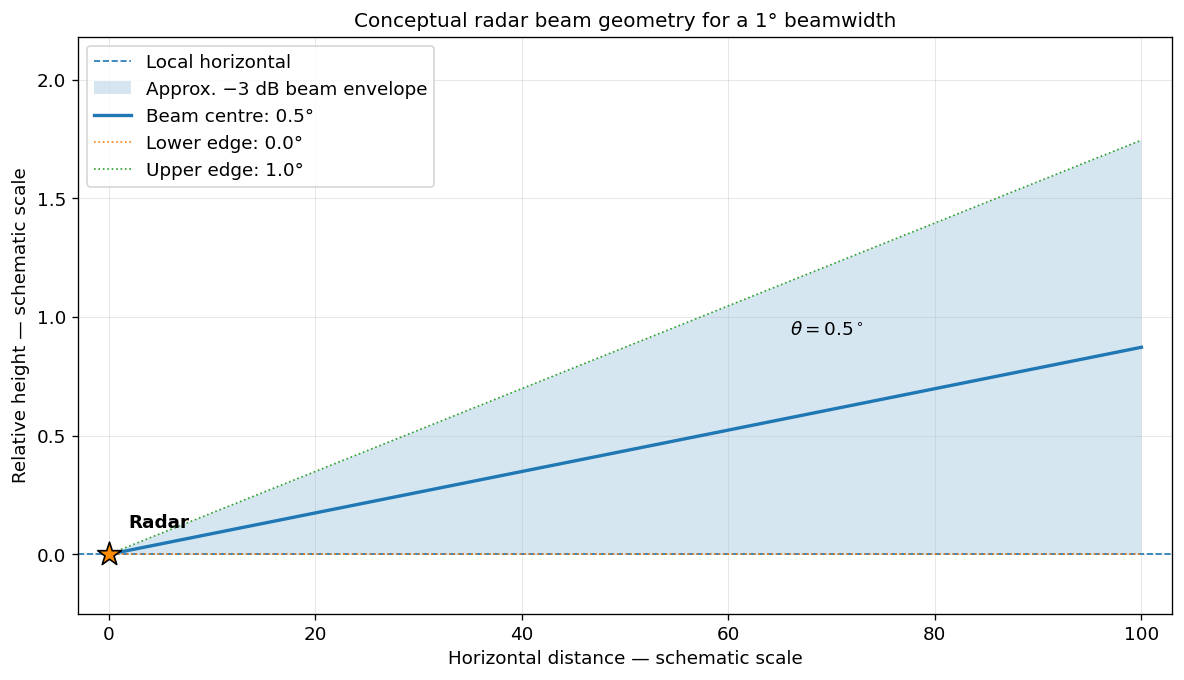

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig02_01_Conceptual_Radar_Beam_Geometry.png


In [8]:

# ============================================================
# STEP 8 — Figure 1: conceptual beam geometry
# ============================================================

theta_demo_deg = 0.5
half_bw_deg = BEAMWIDTH_DEG / 2.0

theta_c = np.deg2rad(theta_demo_deg)
theta_l = np.deg2rad(theta_demo_deg - half_bw_deg)
theta_u = np.deg2rad(theta_demo_deg + half_bw_deg)

x_demo = np.linspace(0.0, 100.0, 300)

y_center = x_demo * np.tan(theta_c)
y_lower = x_demo * np.tan(theta_l)
y_upper = x_demo * np.tan(theta_u)

fig, ax = plt.subplots(figsize=(10.0, 5.8))

# Local horizontal reference
ax.axhline(
    0.0,
    linewidth=1.0,
    linestyle="--",
    label="Local horizontal",
)

# Beam envelope and center line
ax.fill_between(
    x_demo,
    y_lower,
    y_upper,
    alpha=0.18,
    label="Approx. −3 dB beam envelope",
)

ax.plot(
    x_demo,
    y_center,
    linewidth=2.0,
    label="Beam centre: 0.5°",
)

ax.plot(
    x_demo,
    y_lower,
    linewidth=1.0,
    linestyle=":",
    label="Lower edge: 0.0°",
)

ax.plot(
    x_demo,
    y_upper,
    linewidth=1.0,
    linestyle=":",
    label="Upper edge: 1.0°",
)

# Radar symbol is deliberately not blue.
ax.scatter(
    [0.0],
    [0.0],
    marker="*",
    s=220,
    facecolor=CURRENT_FACE,
    edgecolor=CURRENT_EDGE,
    linewidth=1.0,
    zorder=10,
)

ax.annotate(
    "Radar",
    (0.0, 0.0),
    xytext=(12, 16),
    textcoords="offset points",
    fontweight="bold",
)

ax.text(
    66,
    y_center[np.searchsorted(x_demo, 66)] + 0.35,
    r"$\theta=0.5^\circ$",
    fontsize=11,
)

ax.set_xlabel("Horizontal distance — schematic scale")
ax.set_ylabel("Relative height — schematic scale")
ax.set_title(
    "Conceptual radar beam geometry for a 1° beamwidth"
)
ax.set_xlim(-3, 103)
ax.set_ylim(-0.25, max(y_upper) * 1.25)
ax.legend(loc="upper left")
ax.grid(True, linewidth=0.4, alpha=0.45)

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    "Fig02_01_Conceptual_Radar_Beam_Geometry.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig1_path)



## 13. คำนวณ Beam Height ที่ระยะสำคัญ

เราจะตรวจ beam centre ที่ระยะ

$$
50,\ 100,\ 150,\ 200,\ 240\ \mathrm{km}
$$

สำหรับ elevation angles ทั้ง 4 ค่า

ตารางนี้ช่วยให้นิสิตสร้าง intuition ก่อนดูกราฟ


In [9]:

# ============================================================
# STEP 9 — Beam-height table at selected ranges
# ============================================================

selected_ranges_km = np.array(
    [50, 100, 150, 200, 240],
    dtype=float,
)

table_rows = []

for elev in ELEVATIONS_DEG:
    for r_km in selected_ranges_km:
        h_m = beam_height_above_antenna(
            r_km * 1000.0,
            elev,
        )

        ground_arc_m = beam_ground_arc_distance(
            r_km * 1000.0,
            elev,
        )

        table_rows.append({
            "elevation_deg": elev,
            "slant_range_km": r_km,
            "beam_height_above_antenna_m": h_m,
            "effective_ground_arc_km": (
                ground_arc_m / 1000.0
            ),
        })

beam_height_table = pd.DataFrame(
    table_rows
)

display(
    beam_height_table.style.format({
        "elevation_deg": "{:.1f}",
        "slant_range_km": "{:.0f}",
        "beam_height_above_antenna_m": "{:.1f}",
        "effective_ground_arc_km": "{:.2f}",
    })
)

beam_height_csv = (
    TABLES_DIR /
    "02_beam_height_selected_ranges.csv"
)

beam_height_table.to_csv(
    beam_height_csv,
    index=False,
)

print("\nSaved:")
print(beam_height_csv)


,elevation_deg,slant_range_km,beam_height_above_antenna_m,effective_ground_arc_km
0,0.5,50,583.5,49.99
1,0.5,100,1461.1,99.98
2,0.5,150,2632.9,149.96
3,0.5,200,4098.7,199.91
4,0.5,240,5483.0,239.87
5,1.0,50,1019.7,49.99
6,1.0,100,2333.5,99.96
7,1.0,150,3941.3,149.92
8,1.0,200,5842.9,199.85
9,1.0,240,7575.6,239.78



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/02_beam_height_selected_ranges.csv



## 14. Figure 2 — Beam Centre Height vs Range

กราฟนี้เป็นแกนหลักของบทเรียน

แกนตั้งเป็น

$$
h_{\mathrm{beam}}
-
H_{\mathrm{antenna}}
$$

ดังนั้นเป็น **beam height above antenna reference** และยังไม่ขึ้นกับ radar site ใดเป็นพิเศษ

สิ่งที่ควรสังเกต:

- beam height เพิ่มตาม range
- elevation ที่สูงกว่าจะเพิ่มระดับเร็วกว่า
- ความสัมพันธ์ไม่เป็นเส้นตรงอย่างสมบูรณ์เพราะ Earth curvature


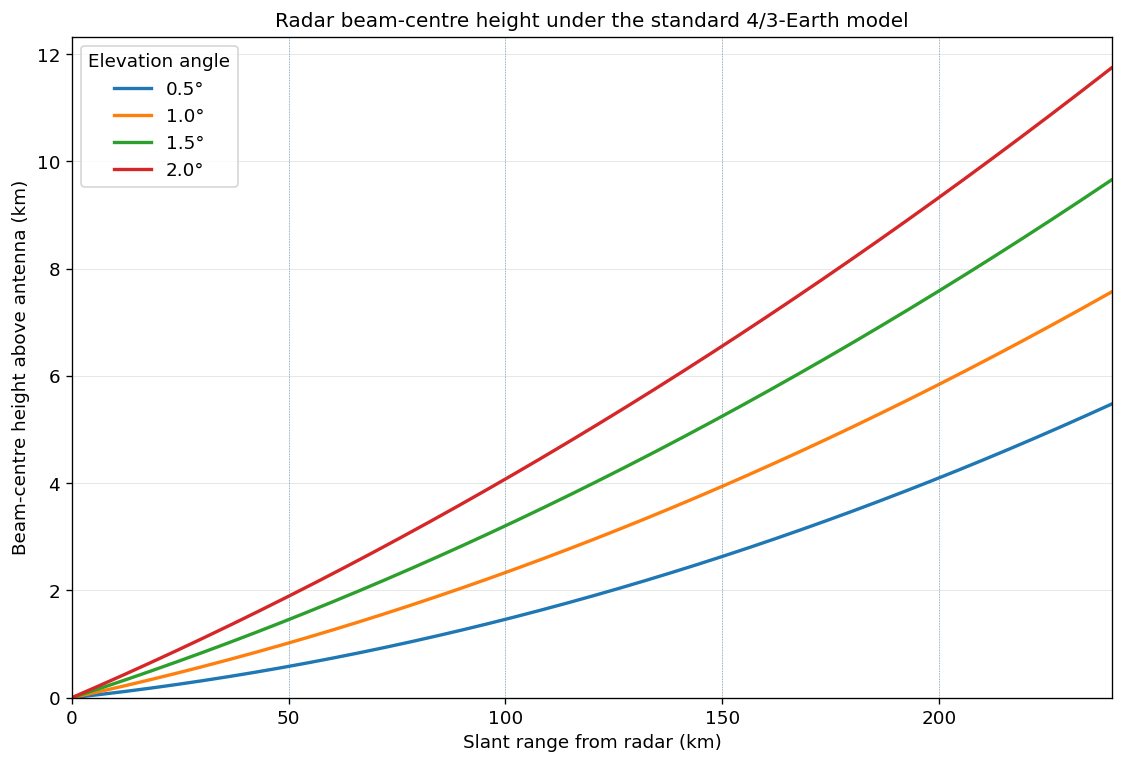

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig02_02_Beam_Centre_Height_4_Elevations.png


In [10]:

# ============================================================
# STEP 10 — Figure 2: beam-centre height vs slant range
# ============================================================

fig, ax = plt.subplots(figsize=(9.5, 6.5))

for elev in ELEVATIONS_DEG:
    h_km = (
        beam_height_above_antenna(
            range_m,
            elev,
        )
        / 1000.0
    )

    ax.plot(
        range_km,
        h_km,
        linewidth=2.0,
        label=f"{elev:.1f}°",
    )

for x in [50, 100, 150, 200, 240]:
    ax.axvline(
        x,
        linewidth=0.6,
        linestyle=":",
        alpha=0.45,
    )

ax.set_xlabel("Slant range from radar (km)")
ax.set_ylabel("Beam-centre height above antenna (km)")
ax.set_title(
    "Radar beam-centre height under the standard 4/3-Earth model"
)
ax.set_xlim(0, 240)
ax.set_ylim(bottom=0)
ax.grid(True, linewidth=0.4, alpha=0.45)
ax.legend(
    title="Elevation angle",
    loc="upper left",
)

fig.tight_layout()

fig2_path = (
    FIGURES_DIR /
    "Fig02_02_Beam_Centre_Height_4_Elevations.png"
)

fig.savefig(
    fig2_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig2_path)



## 15. Figure 3 — Beam Envelope ของ 0.5° Sweep

สำหรับ nominal elevation

$$
\theta=0.5^\circ
$$

และ beamwidth

$$
\beta=1^\circ
$$

ขอบครึ่งกำลังโดยประมาณคือ

$$
0^\circ
\quad\text{ถึง}\quad
1^\circ
$$

Figure นี้จึงสำคัญมากต่อ beam-blockage analysis เพราะจะแสดงว่า beam มี vertical extent เพิ่มขึ้นตาม range

พื้นที่ระหว่าง lower และ upper edge คือบริเวณที่เรดาร์ส่ง/รับพลังงานส่วนสำคัญ ไม่ใช่เพียงเส้น beam centre


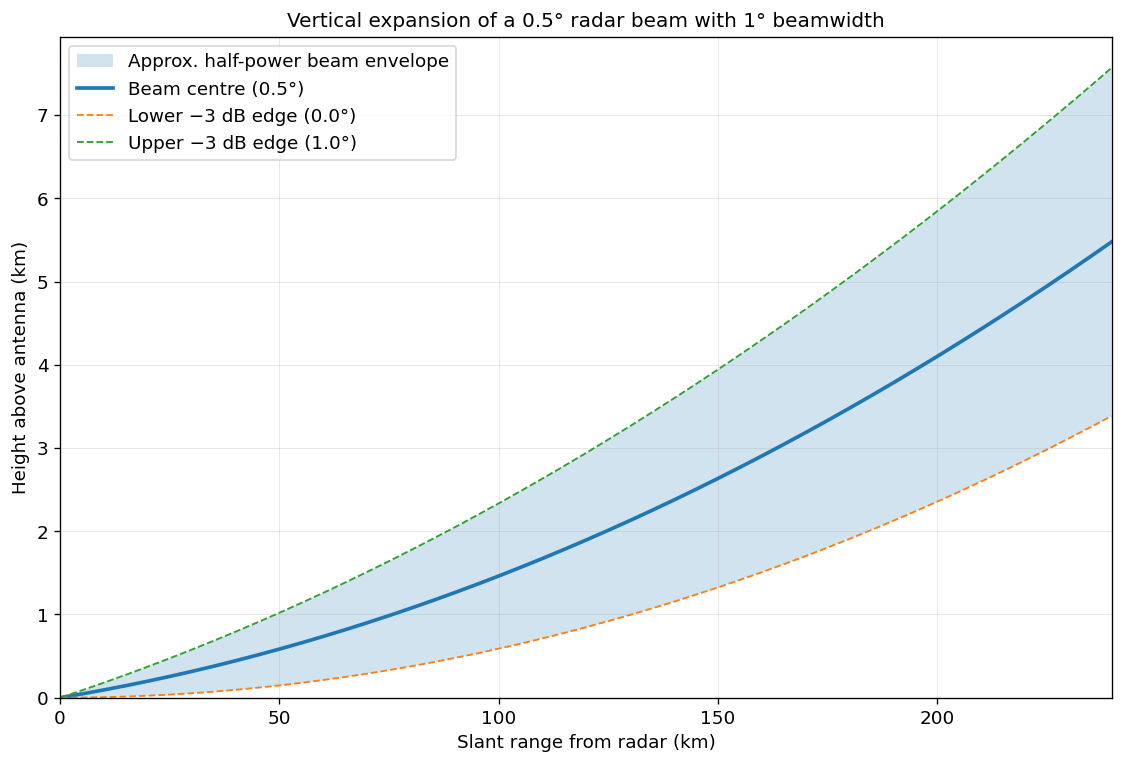

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig02_03_0p5deg_Beam_HalfPower_Envelope.png


In [11]:

# ============================================================
# STEP 11 — Figure 3: half-power beam envelope
# ============================================================

nominal_elev = 0.5

(
    lower_angle,
    upper_angle,
    lower_h,
    upper_h,
) = beam_half_power_edges(
    range_m,
    nominal_elev,
)

center_h = beam_height_above_antenna(
    range_m,
    nominal_elev,
)

fig, ax = plt.subplots(figsize=(9.5, 6.5))

ax.fill_between(
    range_km,
    lower_h / 1000.0,
    upper_h / 1000.0,
    alpha=0.20,
    label="Approx. half-power beam envelope",
)

ax.plot(
    range_km,
    center_h / 1000.0,
    linewidth=2.2,
    label=f"Beam centre ({nominal_elev:.1f}°)",
)

ax.plot(
    range_km,
    lower_h / 1000.0,
    linewidth=1.1,
    linestyle="--",
    label=f"Lower −3 dB edge ({lower_angle:.1f}°)",
)

ax.plot(
    range_km,
    upper_h / 1000.0,
    linewidth=1.1,
    linestyle="--",
    label=f"Upper −3 dB edge ({upper_angle:.1f}°)",
)

ax.set_xlabel("Slant range from radar (km)")
ax.set_ylabel("Height above antenna (km)")
ax.set_title(
    "Vertical expansion of a 0.5° radar beam with 1° beamwidth"
)
ax.set_xlim(0, 240)
ax.set_ylim(bottom=0)
ax.grid(True, linewidth=0.4, alpha=0.45)
ax.legend(loc="upper left")

fig.tight_layout()

fig3_path = (
    FIGURES_DIR /
    "Fig02_03_0p5deg_Beam_HalfPower_Envelope.png"
)

fig.savefig(
    fig3_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig3_path)



## 16. Beam Width เพิ่มขึ้นตามระยะอย่างไร?

จาก approximation

$$
a(r)
=
r\tan\left(\frac{\beta}{2}\right)
$$

สามารถคำนวณ approximate half-power beam diameter ได้จาก

$$
D_{\mathrm{beam}}
=
2r\tan\left(\frac{\beta}{2}\right)
$$

ลองพิจารณาว่าที่ระยะ 240 km ลำบีมกว้างกี่ km

นี่ช่วยอธิบายว่าทำไม terrain obstacle ที่อยู่ไกลจึงต้องพิจารณาพื้นที่หน้าตัดของ beam ไม่ใช่จุดเดียว


In [12]:

# ============================================================
# STEP 12 — Beam-width table
# ============================================================

beam_width_rows = []

for r_km in selected_ranges_km:
    radius_m = approximate_beam_radius(
        r_km * 1000.0
    )

    beam_width_rows.append({
        "slant_range_km": r_km,
        "half_power_radius_m": radius_m,
        "approx_beam_diameter_m": 2.0 * radius_m,
    })

beam_width_table = pd.DataFrame(
    beam_width_rows
)

display(
    beam_width_table.style.format({
        "slant_range_km": "{:.0f}",
        "half_power_radius_m": "{:.1f}",
        "approx_beam_diameter_m": "{:.1f}",
    })
)

beam_width_csv = (
    TABLES_DIR /
    "02_beam_width_selected_ranges.csv"
)

beam_width_table.to_csv(
    beam_width_csv,
    index=False,
)

print("\nSaved:")
print(beam_width_csv)


,slant_range_km,half_power_radius_m,approx_beam_diameter_m
0,50,436.3,872.7
1,100,872.7,1745.4
2,150,1309.0,2618.1
3,200,1745.4,3490.7
4,240,2094.4,4188.9



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/02_beam_width_selected_ranges.csv



# Part D — Atmospheric Assumption

## 17. Figure 4 — Sensitivity ต่อค่า k

Standard model ใช้

$$
k=\frac{4}{3}
$$

แต่ในบรรยากาศจริง refractivity gradient สามารถเปลี่ยนได้

เพื่อแสดง sensitivity เราจะเปรียบเทียบ

$$
k=1.0,\quad
k=\frac{4}{3},\quad
k=1.5
$$

สำหรับ elevation $0.5^\circ$

นี่เป็น **conceptual sensitivity experiment** ไม่ใช่การวินิจฉัย refractivity จริงของเหตุการณ์ใดเหตุการณ์หนึ่ง


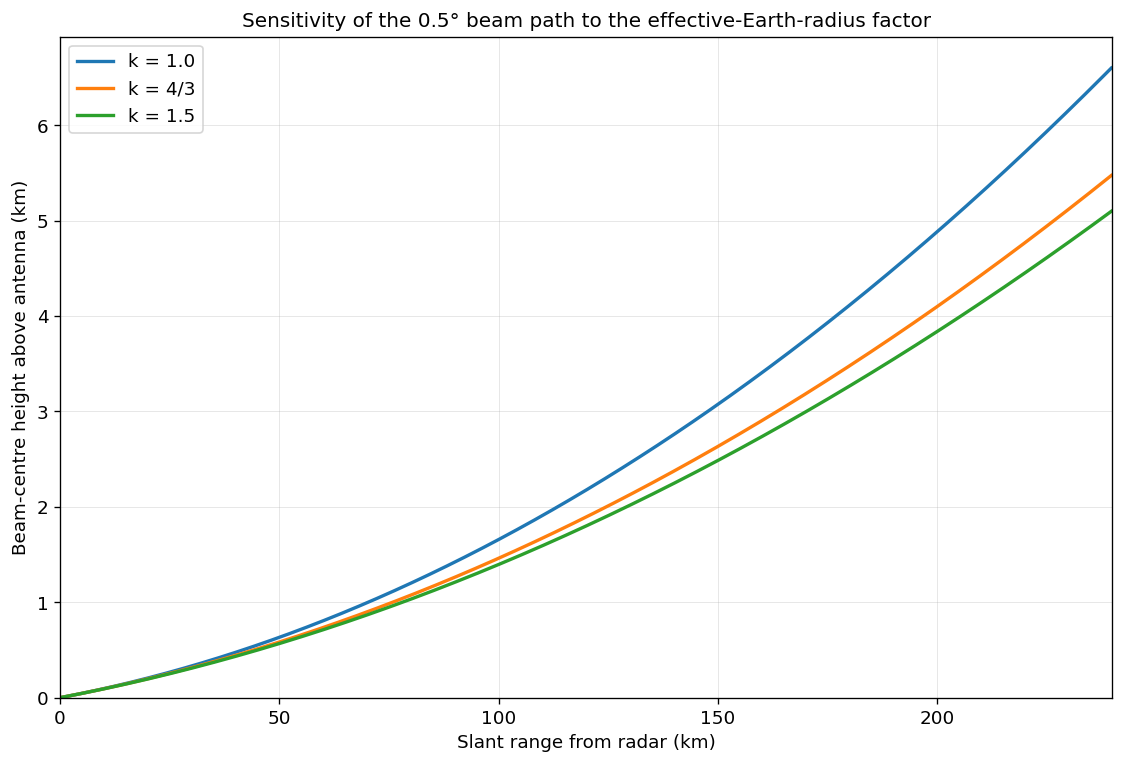

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig02_04_0p5deg_Beam_kFactor_Sensitivity.png


In [13]:

# ============================================================
# STEP 13 — Figure 4: k-factor sensitivity
# ============================================================

k_cases = [
    (1.0, "k = 1.0"),
    (4.0 / 3.0, "k = 4/3"),
    (1.5, "k = 1.5"),
]

fig, ax = plt.subplots(figsize=(9.5, 6.5))

for k_value, label in k_cases:
    h_km = (
        beam_height_above_antenna(
            range_m,
            0.5,
            k=k_value,
        )
        / 1000.0
    )

    ax.plot(
        range_km,
        h_km,
        linewidth=2.0,
        label=label,
    )

ax.set_xlabel("Slant range from radar (km)")
ax.set_ylabel("Beam-centre height above antenna (km)")
ax.set_title(
    "Sensitivity of the 0.5° beam path to the effective-Earth-radius factor"
)
ax.set_xlim(0, 240)
ax.set_ylim(bottom=0)
ax.grid(True, linewidth=0.4, alpha=0.45)
ax.legend(loc="upper left")

fig.tight_layout()

fig4_path = (
    FIGURES_DIR /
    "Fig02_04_0p5deg_Beam_kFactor_Sensitivity.png"
)

fig.savefig(
    fig4_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig4_path)



# Part E — จาก Relative Beam Height สู่ MSL

## 18. Ground Elevation ของแต่ละ Site

Beam geometry ที่วัด **เหนือ antenna** เหมือนกันสำหรับ radar ที่ใช้ elevation/range เดียวกัน

แต่ beam altitude MSL แตกต่างกัน เพราะ radar แต่ละ site มี ground elevation ต่างกัน

ในบทนี้ใช้

$$
H_{\mathrm{radar,MSL}}
=
H_{\mathrm{nativeDEM}}
+
30\ \mathrm{m}
$$

โดย 30 m เป็น teaching assumption

ดังนั้น site ที่อยู่สูง เช่น CAND_C จะทำให้ beam ทั้งชุดถูกยกสูงขึ้นในกรอบ MSL

อย่างไรก็ตาม:

> **site สูงกว่า ไม่ได้แปลว่า site ดีกว่าโดยอัตโนมัติ**

ต้องพิจารณา terrain horizon และ beam blockage รอบทุก azimuth ในบทต่อ ๆ ไป


In [14]:

# ============================================================
# STEP 14 — Radar antenna altitude MSL for teaching comparison
# ============================================================

sites["antenna_agl_assumed_m"] = ANTENNA_AGL_M

sites["antenna_msl_assumed_m"] = (
    sites["native_dem_m"]
    + ANTENNA_AGL_M
)

display(
    sites[
        [
            "site_id",
            "site_name",
            "native_dem_m",
            "antenna_agl_assumed_m",
            "antenna_msl_assumed_m",
        ]
    ].style.format({
        "native_dem_m": "{:.1f}",
        "antenna_agl_assumed_m": "{:.1f}",
        "antenna_msl_assumed_m": "{:.1f}",
    })
)


,site_id,site_name,native_dem_m,antenna_agl_assumed_m,antenna_msl_assumed_m
0,CURRENT,"Tha Wang Pha, Nan",233.0,30.0,263.0
1,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0,30.0,265.0
2,CAND_B,"Woranakhon, Pua, Nan",347.0,30.0,377.0
3,CAND_C,"Phu Kha, Pua, Nan",1296.0,30.0,1326.0



## 19. Figure 5 — Site-specific Beam Altitude MSL

เพื่อแยกสองแนวคิดให้ชัด:

### Relative geometry

$$
h_{\mathrm{beam}}
$$

ขึ้นกับ range, elevation, Earth curvature และ refraction

### Absolute altitude

$$
H_{\mathrm{beam,MSL}}
=
H_{\mathrm{radar,MSL}}
+
h_{\mathrm{beam}}
$$

จึงขึ้นกับระดับความสูงของ site ด้วย

Figure นี้เปรียบเทียบทั้ง 4 sites ที่ elevation $0.5^\circ$ ภายใต้ antenna-height assumption เดียวกัน


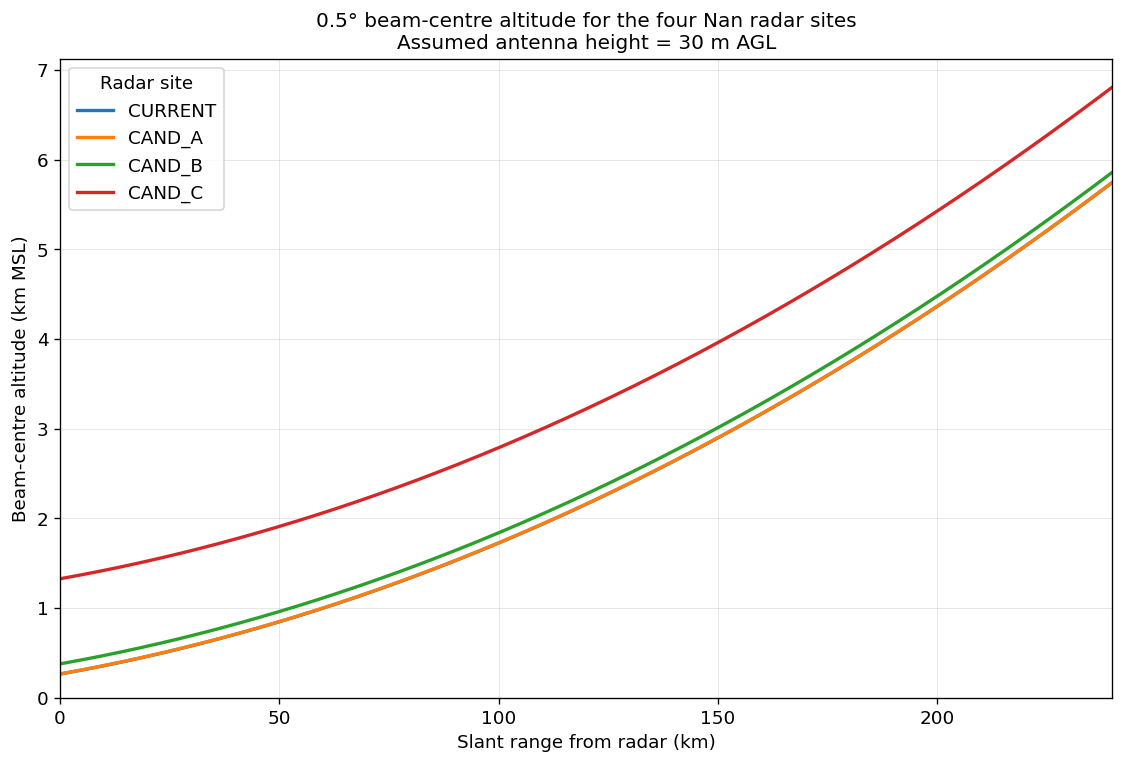

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig02_05_0p5deg_Beam_Altitude_MSL_4Sites.png


In [15]:

# ============================================================
# STEP 15 — Figure 5: site-specific 0.5° beam altitude MSL
# ============================================================

focus_elev = 0.5
relative_h_m = beam_height_above_antenna(
    range_m,
    focus_elev,
)

fig, ax = plt.subplots(figsize=(9.5, 6.5))

for _, site in sites.iterrows():
    beam_msl_km = (
        site["antenna_msl_assumed_m"]
        + relative_h_m
    ) / 1000.0

    ax.plot(
        range_km,
        beam_msl_km,
        linewidth=2.0,
        label=site["site_id"],
    )

ax.set_xlabel("Slant range from radar (km)")
ax.set_ylabel("Beam-centre altitude (km MSL)")
ax.set_title(
    "0.5° beam-centre altitude for the four Nan radar sites\n"
    f"Assumed antenna height = {ANTENNA_AGL_M:.0f} m AGL"
)
ax.set_xlim(0, 240)
ax.set_ylim(bottom=0)
ax.grid(True, linewidth=0.4, alpha=0.45)
ax.legend(
    title="Radar site",
    loc="upper left",
)

fig.tight_layout()

fig5_path = (
    FIGURES_DIR /
    "Fig02_05_0p5deg_Beam_Altitude_MSL_4Sites.png"
)

fig.savefig(
    fig5_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig5_path)



# Part F — Cartographic Context

## 20. Figure 6 — Local Terrain และตำแหน่ง Radar Sites

ในแผนที่ terrain เราจะหลีกเลี่ยงการใช้ marker สีน้ำเงิน เพราะพื้นที่ต่ำของ `terrain` colormap มีสีน้ำเงินอยู่แล้ว

กำหนดมาตรฐานของชุดแบบเรียนดังนี้:

- **Current radar:** ดาวสีส้ม ขอบดำ
- **Candidate radar:** สามเหลี่ยมสีขาว ขอบดำ

และใช้ **manual label offsets** สำหรับ sites ที่อยู่ใกล้กัน เพื่อป้องกันข้อความซ้อนกัน

บนแผนที่จะใช้เพียง short IDs:

- CURRENT
- CAND_A
- CAND_B
- CAND_C

ชื่อเต็มแสดงในตารางแทน เพื่อรักษาความสะอาดของแผนที่


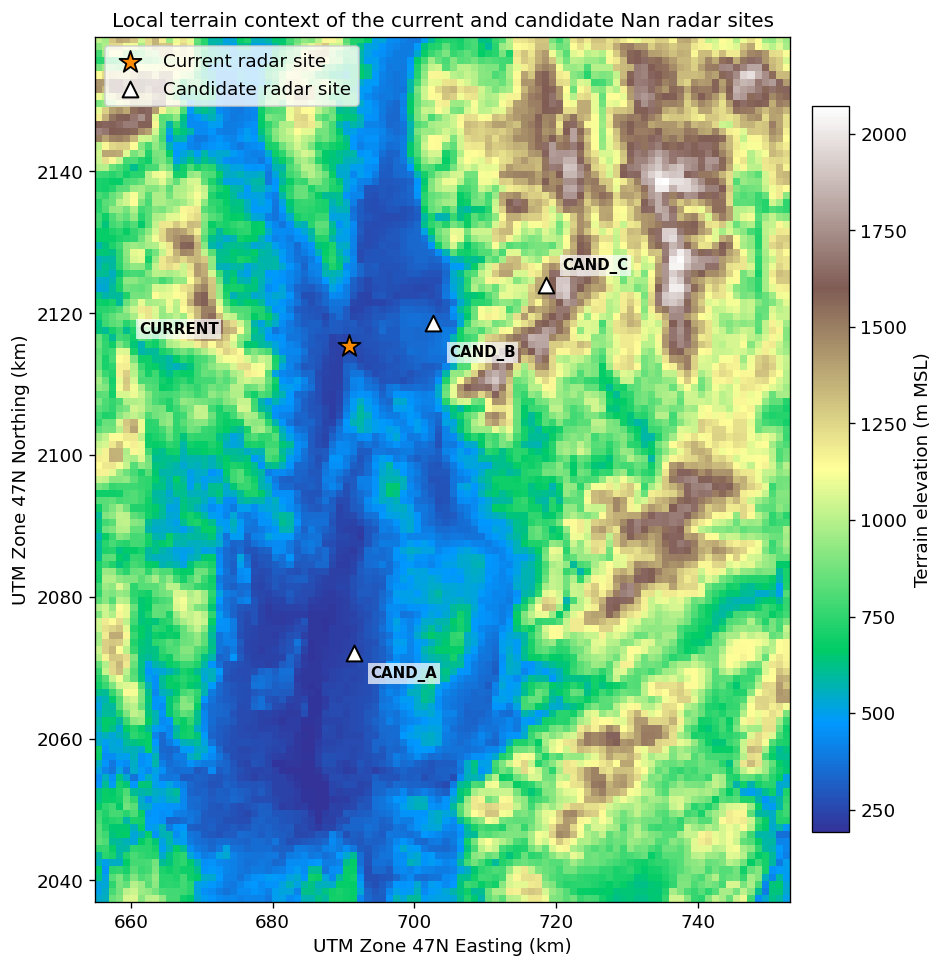

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig02_06_Nan_Radar_Sites_Local_Terrain_Cartography.png


In [16]:

# ============================================================
# STEP 16 — Figure 6: local terrain with publication-safe markers
# ============================================================

local_buffer_m = 35_000.0

local_xmin = sites["utm_x_m"].min() - local_buffer_m
local_xmax = sites["utm_x_m"].max() + local_buffer_m
local_ymin = sites["utm_y_m"].min() - local_buffer_m
local_ymax = sites["utm_y_m"].max() + local_buffer_m

with rasterio.open(DEM_PATH) as ds:
    local_window = rasterio.windows.from_bounds(
        local_xmin,
        local_ymin,
        local_xmax,
        local_ymax,
        transform=ds.transform,
    ).round_offsets().round_lengths()

    local_dem = ds.read(
        1,
        window=local_window,
        masked=True,
    )

    local_bounds = rasterio.windows.bounds(
        local_window,
        ds.transform,
    )

local_extent_km = [
    local_bounds[0] / 1000.0,
    local_bounds[2] / 1000.0,
    local_bounds[1] / 1000.0,
    local_bounds[3] / 1000.0,
]

# Manual, deterministic label offsets to avoid overlap.
label_offsets = {
    "CURRENT": (-78, 10),
    "CAND_A": (10, -12),
    "CAND_B": (10, -18),
    "CAND_C": (10, 12),
}

fig, ax = plt.subplots(figsize=(9.5, 8.2))

im = ax.imshow(
    local_dem,
    cmap=DEM_CMAP,
    extent=local_extent_km,
    origin="upper",
)

for _, site in sites.iterrows():
    x_km = site["utm_x_m"] / 1000.0
    y_km = site["utm_y_m"] / 1000.0

    if site["status"] == "Existing":
        ax.scatter(
            x_km,
            y_km,
            marker=CURRENT_MARKER,
            s=190,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=8,
            label="Current radar site",
        )
    else:
        ax.scatter(
            x_km,
            y_km,
            marker=CANDIDATE_MARKER,
            s=90,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=1.2,
            zorder=8,
            label="Candidate radar site",
        )

    dx, dy = label_offsets.get(
        site["site_id"],
        (8, 8),
    )

    ax.annotate(
        site["site_id"],
        xy=(x_km, y_km),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        ha="left" if dx >= 0 else "right",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72,
            "pad": 1.5,
        },
        zorder=9,
    )

# Remove duplicate legend entries while preserving order.
handles, labels = ax.get_legend_handles_labels()
unique = {}

for h, label in zip(handles, labels):
    if label not in unique:
        unique[label] = h

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper left",
)

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.84,
    pad=0.02,
)

cbar.set_label(
    "Terrain elevation (m MSL)"
)

ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)
ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)
ax.set_title(
    "Local terrain context of the current and candidate Nan radar sites"
)
ax.set_aspect(
    "equal",
    adjustable="box",
)

fig.tight_layout()

fig6_path = (
    FIGURES_DIR /
    "Fig02_06_Nan_Radar_Sites_Local_Terrain_Cartography.png"
)

fig.savefig(
    fig6_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig6_path)



## 21. ตาราง Beam Altitude MSL ที่ระยะสำคัญ

ตารางนี้รวม site elevation กับ beam geometry

ใช้สำหรับฝึกแยกให้เห็นว่า

$$
\text{ต่าง site}
\rightarrow
\text{ต่าง starting altitude}
$$

แต่

$$
\text{geometry increment เหนือ antenna}
$$

ยังเหมือนกันภายใต้ elevation, range และ $k$ เดียวกัน


In [17]:

# ============================================================
# STEP 17 — Site-specific MSL beam table
# ============================================================

site_beam_rows = []

for _, site in sites.iterrows():
    for elev in ELEVATIONS_DEG:
        for r_km in selected_ranges_km:
            relative_m = beam_height_above_antenna(
                r_km * 1000.0,
                elev,
            )

            site_beam_rows.append({
                "site_id": site["site_id"],
                "site_name": site["site_name"],
                "native_ground_msl_m": site["native_dem_m"],
                "assumed_antenna_agl_m": ANTENNA_AGL_M,
                "assumed_antenna_msl_m": site["antenna_msl_assumed_m"],
                "elevation_deg": elev,
                "slant_range_km": r_km,
                "beam_height_above_antenna_m": relative_m,
                "beam_altitude_msl_m": (
                    site["antenna_msl_assumed_m"]
                    + relative_m
                ),
            })

site_beam_table = pd.DataFrame(
    site_beam_rows
)

display(
    site_beam_table[
        [
            "site_id",
            "elevation_deg",
            "slant_range_km",
            "beam_height_above_antenna_m",
            "beam_altitude_msl_m",
        ]
    ].style.format({
        "elevation_deg": "{:.1f}",
        "slant_range_km": "{:.0f}",
        "beam_height_above_antenna_m": "{:.1f}",
        "beam_altitude_msl_m": "{:.1f}",
    })
)

site_beam_csv = (
    TABLES_DIR /
    "02_site_specific_beam_altitude_MSL.csv"
)

site_beam_table.to_csv(
    site_beam_csv,
    index=False,
)

print("\nSaved:")
print(site_beam_csv)


,site_id,elevation_deg,slant_range_km,beam_height_above_antenna_m,beam_altitude_msl_m
0,CURRENT,0.5,50,583.5,846.5
1,CURRENT,0.5,100,1461.1,1724.1
2,CURRENT,0.5,150,2632.9,2895.9
3,CURRENT,0.5,200,4098.7,4361.7
4,CURRENT,0.5,240,5483.0,5746.0
5,CURRENT,1.0,50,1019.7,1282.7
6,CURRENT,1.0,100,2333.5,2596.5
7,CURRENT,1.0,150,3941.3,4204.3
8,CURRENT,1.0,200,5842.9,6105.9
9,CURRENT,1.0,240,7575.6,7838.6



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/02_site_specific_beam_altitude_MSL.csv



# Part G — การตีความก่อนเข้าสู่ Terrain–Beam Interaction

## 22. สิ่งที่ Figure และ Table ยังตอบไม่ได้

แม้ CAND_C จะมี ground elevation สูงกว่า sites อื่นมาก แต่เรายังตอบไม่ได้ว่าเป็น radar site ที่ดีที่สุด

เพราะคำถามของ site selection ไม่ใช่เพียง

$$
H_{\mathrm{site}}
$$

แต่ต้องพิจารณาอย่างน้อย

$$
H_{\mathrm{terrain}}(r,\alpha)
$$

เทียบกับ

$$
H_{\mathrm{beam}}(r,\theta)
$$

รอบทุก azimuth

ดังนั้นขั้นต่อไปจะเป็น

$$
\boxed{
\text{Beam geometry}
+
\text{DEM sampled along azimuth}
\rightarrow
\text{Terrain–beam profile}
}
$$

หลังจากเข้าใจ interaction นี้แล้ว จึงค่อยเข้าสู่ PBB และ CBB



## 23. แบบฝึกคิด

### CORE

1. ที่ range 100 km beam centre ของ elevation $0.5^\circ$ อยู่สูงจาก antenna กี่ metre?
2. ที่ range 240 km beam centre ของ elevation $2.0^\circ$ อยู่สูงจาก antenna เท่าใด?
3. beamwidth $1^\circ$ ทำให้ lower/upper edge ของ $0.5^\circ$ sweep เป็นมุมใด?
4. approximate beam diameter ที่ 240 km มีค่าประมาณเท่าใด?

### ADVANCED

5. เปรียบเทียบ $h_{\mathrm{flat}}=r\sin\theta$ กับ 4/3-Earth beam height ที่ 200 km
6. อธิบายว่าทำไมการเปลี่ยน $k$ จึงมีผลมากขึ้นเมื่อ range เพิ่ม
7. ถ้า beamwidth เปลี่ยนจาก $1^\circ$ เป็น $0.5^\circ$ vertical beam envelope จะเปลี่ยนอย่างไร?

### RESEARCH EXTENSION

8. Atmospheric refractivity profile แบบใดอาจทำให้ $k=4/3$ ไม่เหมาะสม?
9. ใน terrain-blockage study ควรรายงาน sensitivity ต่อ $k$ หรือไม่ และในสถานการณ์ใด?
10. เพราะเหตุใด antenna altitude จาก engineering survey จึงสำคัญกว่าการใช้ 1-km DEM cell เมื่อประเมิน site จริง?


In [18]:

# ============================================================
# STEP 18 — Save geometry metadata and final readiness check
# ============================================================

geometry_metadata = {
    "earth_radius_m": EARTH_RADIUS_M,
    "k_standard": K_STANDARD,
    "effective_earth_radius_m": EFFECTIVE_EARTH_RADIUS_M,
    "number_of_range_bins": NBINS,
    "range_resolution_m": RANGE_RES_M,
    "maximum_nominal_range_km": MAX_RANGE_M / 1000.0,
    "gate_range_reference": "gate centre",
    "elevation_angles_deg": ELEVATIONS_DEG.tolist(),
    "beamwidth_deg": BEAMWIDTH_DEG,
    "beamwidth_interpretation": (
        "nominal one-way half-power beamwidth"
    ),
    "antenna_agl_teaching_assumption_m": ANTENNA_AGL_M,
    "antenna_height_note": (
        "Teaching assumption only; replace with surveyed or "
        "engineering antenna altitude for operational siting."
    ),
    "site_ground_elevation_source": (
        "native_dem_m from Notebook 01"
    ),
    "dem_path": str(DEM_PATH),
}

geometry_json = (
    METADATA_DIR /
    "02_radar_beam_geometry_parameters.json"
)

with open(
    geometry_json,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        geometry_metadata,
        f,
        indent=2,
        ensure_ascii=False,
    )

# Numerical checks
height_05_240 = beam_height_above_antenna(
    240_000.0,
    0.5,
)

height_20_240 = beam_height_above_antenna(
    240_000.0,
    2.0,
)

beam_diameter_240 = (
    2.0 *
    approximate_beam_radius(
        240_000.0
    )
)

final_checks = {
    "Notebook 01 DEM loaded": DEM_PATH.exists(),
    "Site metadata loaded": len(sites) == 4,
    "All native site elevations finite": bool(
        np.isfinite(
            sites["native_dem_m"].to_numpy(dtype=float)
        ).all()
    ),
    "0.5° beam height at 240 km is positive": (
        height_05_240 > 0
    ),
    "2.0° beam is higher than 0.5° at 240 km": (
        height_20_240 > height_05_240
    ),
    "Beam diameter at 240 km is positive": (
        beam_diameter_240 > 0
    ),
    "Geometry metadata JSON saved": geometry_json.exists(),
    "Selected-range beam table saved": beam_height_csv.exists(),
    "Site-specific beam table saved": site_beam_csv.exists(),
}

print("=" * 78)
print("NOTEBOOK 02 — FINAL READINESS CHECK")
print("=" * 78)

all_ok = True

for label, status in final_checks.items():
    print(("✓" if status else "✗"), label)
    all_ok = all_ok and status

print("=" * 78)

print()
print(
    "0.5° beam centre at 240 km :",
    f"{height_05_240/1000:.3f} km above antenna",
)
print(
    "2.0° beam centre at 240 km :",
    f"{height_20_240/1000:.3f} km above antenna",
)
print(
    "Approx. 1° beam diameter at 240 km:",
    f"{beam_diameter_240/1000:.3f} km",
)

if all_ok:
    print(
        "\n✓ BEAM GEOMETRY READY — proceed to Notebook 03: "
        "Terrain Sampling and Terrain–Beam Profiles."
    )
else:
    raise RuntimeError(
        "One or more geometry QC checks failed."
    )


NOTEBOOK 02 — FINAL READINESS CHECK
✓ Notebook 01 DEM loaded
✓ Site metadata loaded
✓ All native site elevations finite
✓ 0.5° beam height at 240 km is positive
✓ 2.0° beam is higher than 0.5° at 240 km
✓ Beam diameter at 240 km is positive
✓ Geometry metadata JSON saved
✓ Selected-range beam table saved
✓ Site-specific beam table saved

0.5° beam centre at 240 km : 5.483 km above antenna
2.0° beam centre at 240 km : 11.758 km above antenna
Approx. 1° beam diameter at 240 km: 4.189 km

✓ BEAM GEOMETRY READY — proceed to Notebook 03: Terrain Sampling and Terrain–Beam Profiles.



# 24. สรุปบทเรียน

Notebook นี้แยก **beam physics** ออกจาก **terrain interaction** อย่างชัดเจน

เราเริ่มจาก

$$
(r,\theta)
$$

เพิ่ม Earth curvature และ standard atmospheric refraction

$$
R_e^{*}=kR_e
$$

แล้วคำนวณ

$$
h_{\mathrm{beam}}(r,\theta)
$$

จากนั้นเพิ่ม beamwidth เพื่อเปลี่ยนแนวคิดจาก “beam เป็นเส้น” ไปเป็น “beam มีหน้าตัด”

$$
\theta_{\mathrm{lower}}
<
\theta
<
\theta_{\mathrm{upper}}
$$

สุดท้ายจึงนำ site elevation เข้ามาเพื่อหา

$$
H_{\mathrm{beam,MSL}}
$$

### Output สำคัญ

```text
02_metadata/
└── 02_radar_beam_geometry_parameters.json

05_tables/
├── 02_beam_height_selected_ranges.csv
├── 02_beam_width_selected_ranges.csv
└── 02_site_specific_beam_altitude_MSL.csv

04_figures/
├── Fig02_01_Conceptual_Radar_Beam_Geometry.png
├── Fig02_02_Beam_Centre_Height_4_Elevations.png
├── Fig02_03_0p5deg_Beam_HalfPower_Envelope.png
├── Fig02_04_0p5deg_Beam_kFactor_Sensitivity.png
├── Fig02_05_0p5deg_Beam_Altitude_MSL_4Sites.png
└── Fig02_06_Nan_Radar_Sites_Local_Terrain_Cartography.png
```

---

## Next — Notebook 03: Terrain Sampling and Terrain–Beam Profiles

บทถัดไปจะเริ่มนำ

$$
H_{\mathrm{terrain}}(r,\alpha)
$$

มาเปรียบเทียบกับ

$$
H_{\mathrm{beam}}(r,\theta)
$$

ตาม selected azimuths

เพื่อให้นิสิตเห็นด้วยตาว่า ridge ใดอยู่ต่ำกว่า beam centre, เข้าใกล้ lower beam edge หรือทะลุเข้าไปใน beam envelope ก่อนเข้าสู่การคำนวณ PBB/CBB
